In [1]:

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import uproot
import torch
from torch import nn, optim
import pathlib
import os
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import QuantileTransformer, PowerTransformer
#https://link.springer.com/content/pdf/10.1007/978-981-96-7005-5.pdf
# https://www.youtube.com/watch?v=qiUEgSCyY5o

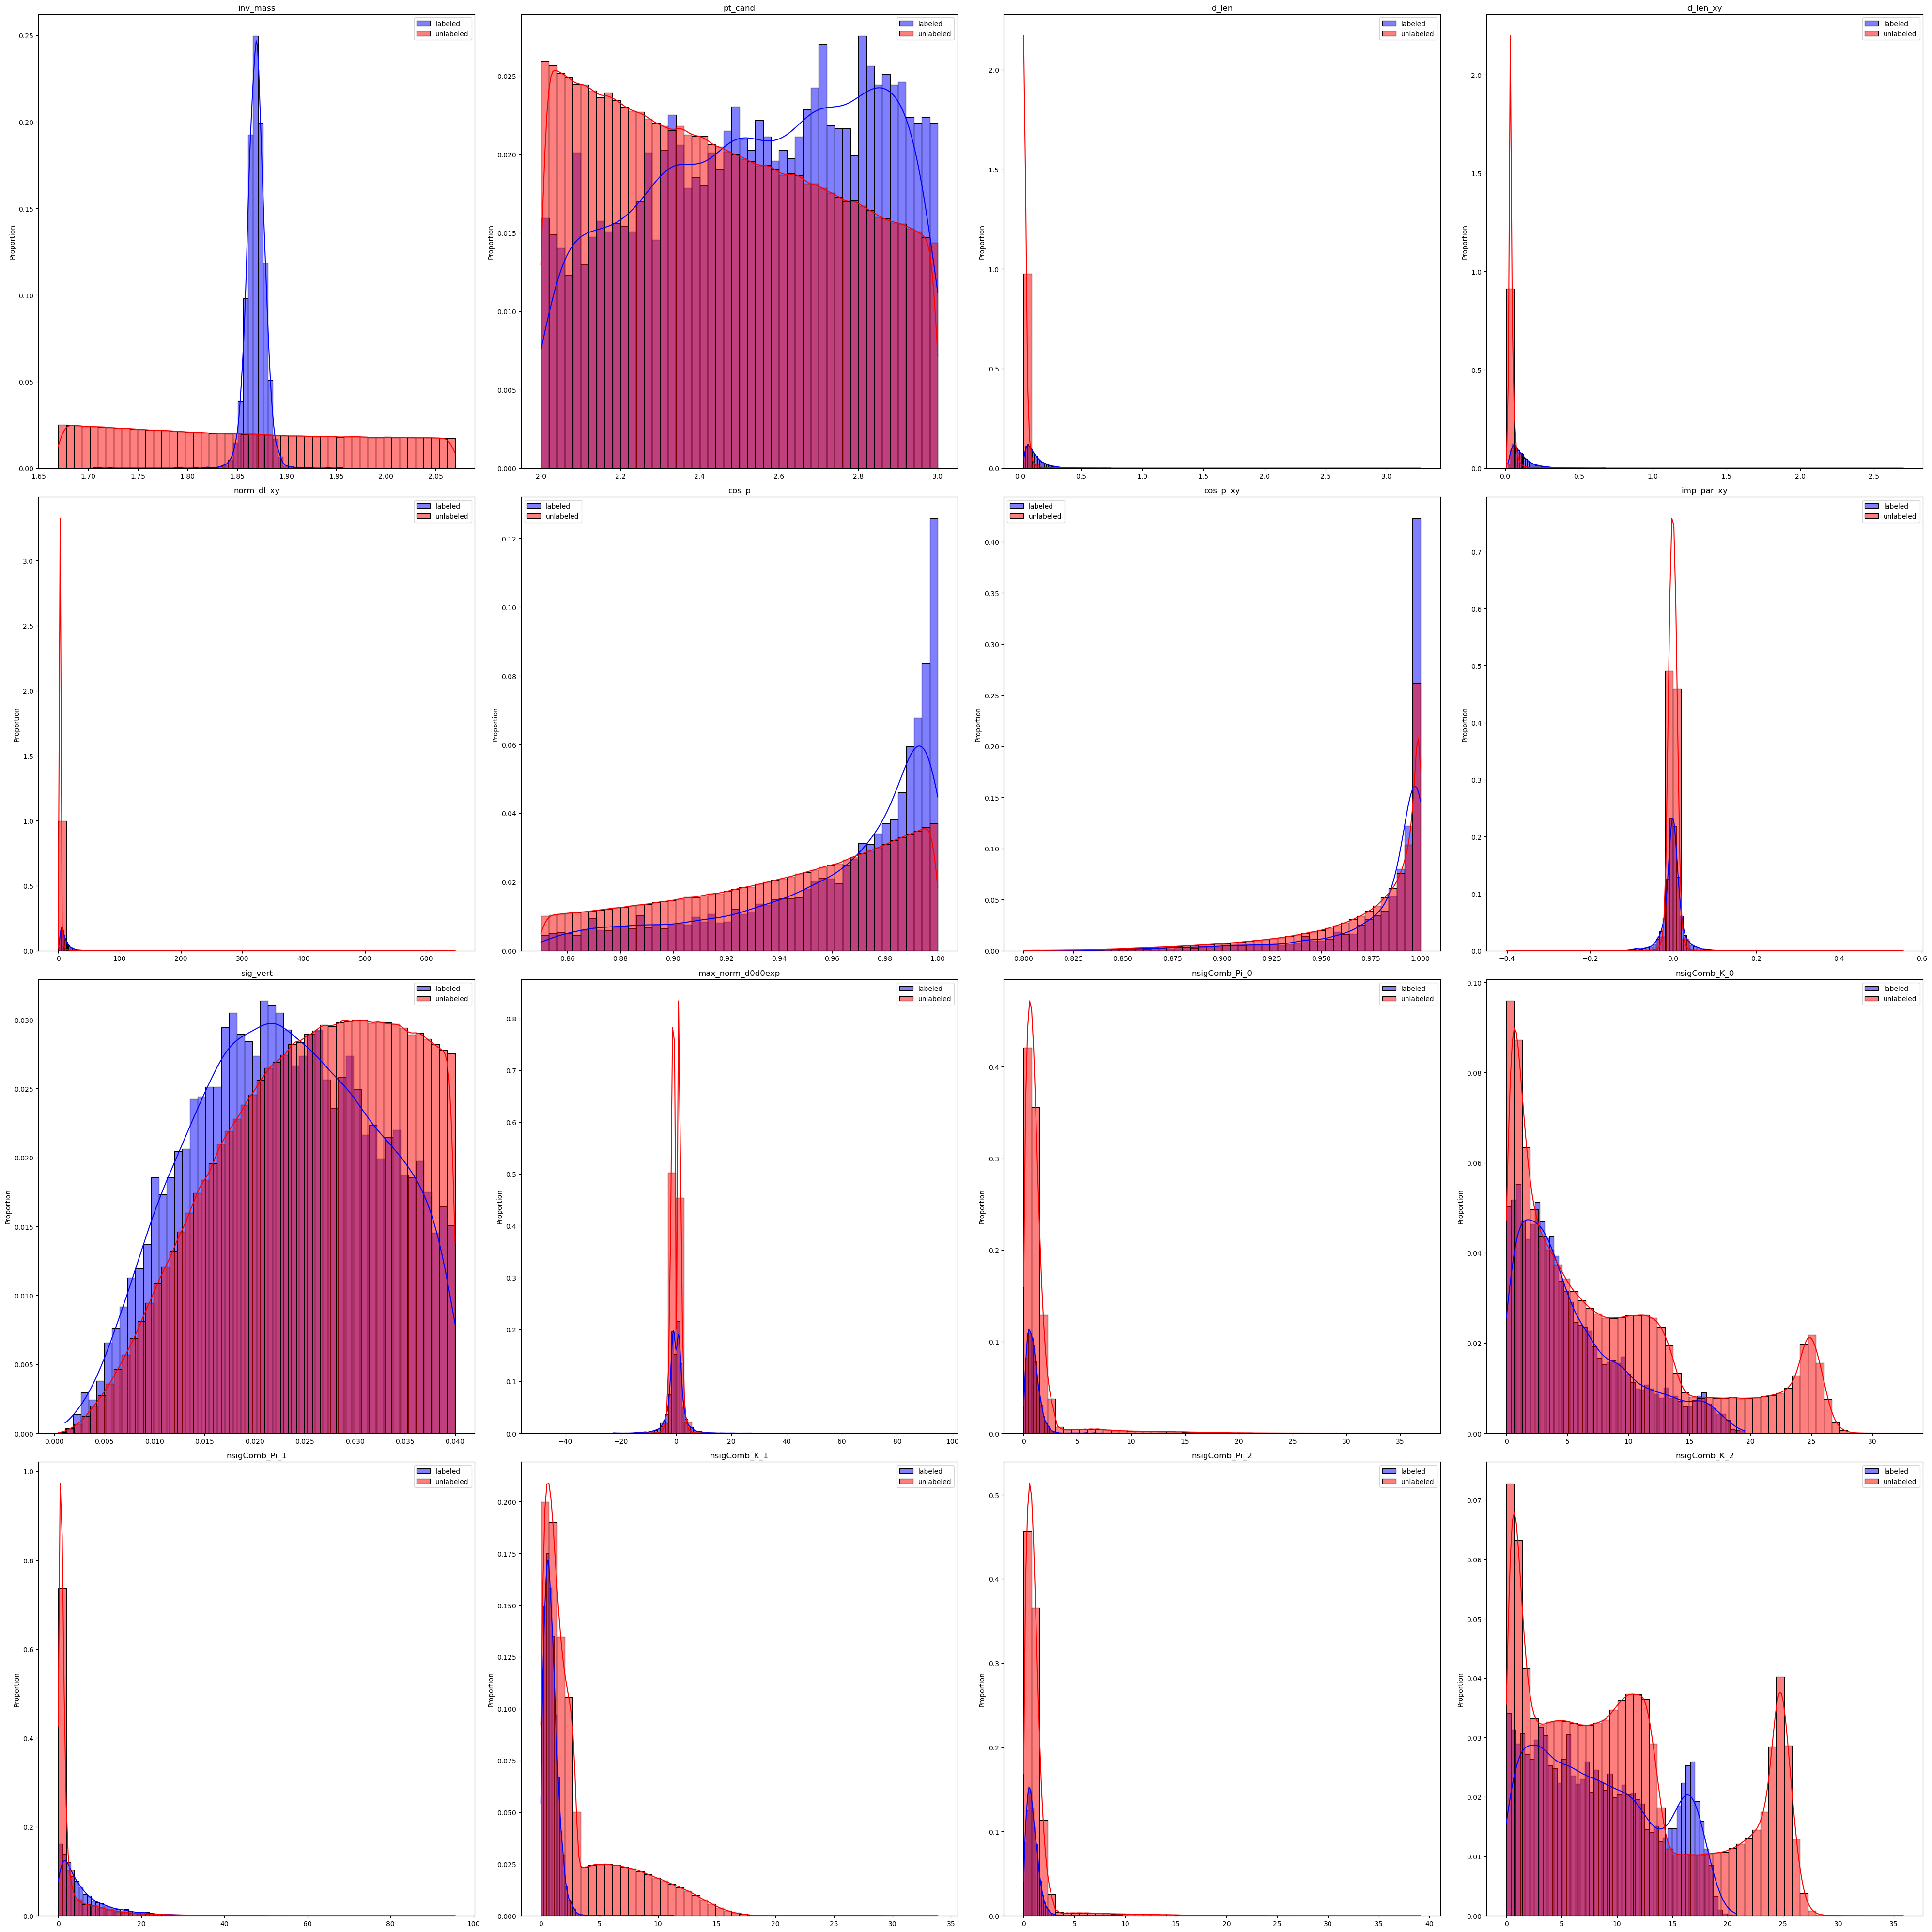

In [2]:
## _-------------------------- Inladen van de data uit de data bestanden

def loader_to_tensor(loader):
    all_data = []
    for batch in loader:
        # batch is a tuple (features,) because no labels
        all_data.append(batch[0])
    return torch.cat(all_data, dim=0)

# Get the data of the simulated outliers.
with uproot.open(pathlib.Path(r"Training_Data\FD.root")) as file:
    tree = file['treeMLDplus']
    branches = tree.keys()
    training_data_FD = tree.arrays(branches, library="np")
    labeled_anomaly_data_tensor = torch.tensor(pd.DataFrame(training_data_FD).values)

# Get the unlabeled data. Since this data file is very large and we do not use all of it for training, limit to 10.000 datapoints for now
with uproot.open(pathlib.Path(r"Training_Data\data.root")) as file_test:
    tree_test = file_test['treeMLDplus']
    branches_test = tree_test.keys()
    training_data_bkg = tree_test.arrays(branches_test, library="np")
    training_data_bkg_df = pd.DataFrame(training_data_bkg)
    unlabeled_data_tensor = torch.tensor(training_data_bkg_df.values)


fig, axes = plt.subplots(4,4, figsize=(40, 40))
axes = axes.flatten()
for i, col in enumerate(branches):
    sns.histplot(labeled_anomaly_data_tensor[:, i], bins=50, color='blue', alpha=0.5, label='labeled', ax=axes[i],kde=True,stat='proportion')
    sns.histplot(unlabeled_data_tensor[:, i], bins=50, color='red', alpha=0.5, label='unlabeled', ax=axes[i],kde=True,stat='proportion')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()



Normaliseer de gelabelede data met een yeo-johnson transformatie, zodat de distributie een mean van 0 heeft en een std van 1. Pas deze transform ook toe op de ongelabelede data.

KeyboardInterrupt: 

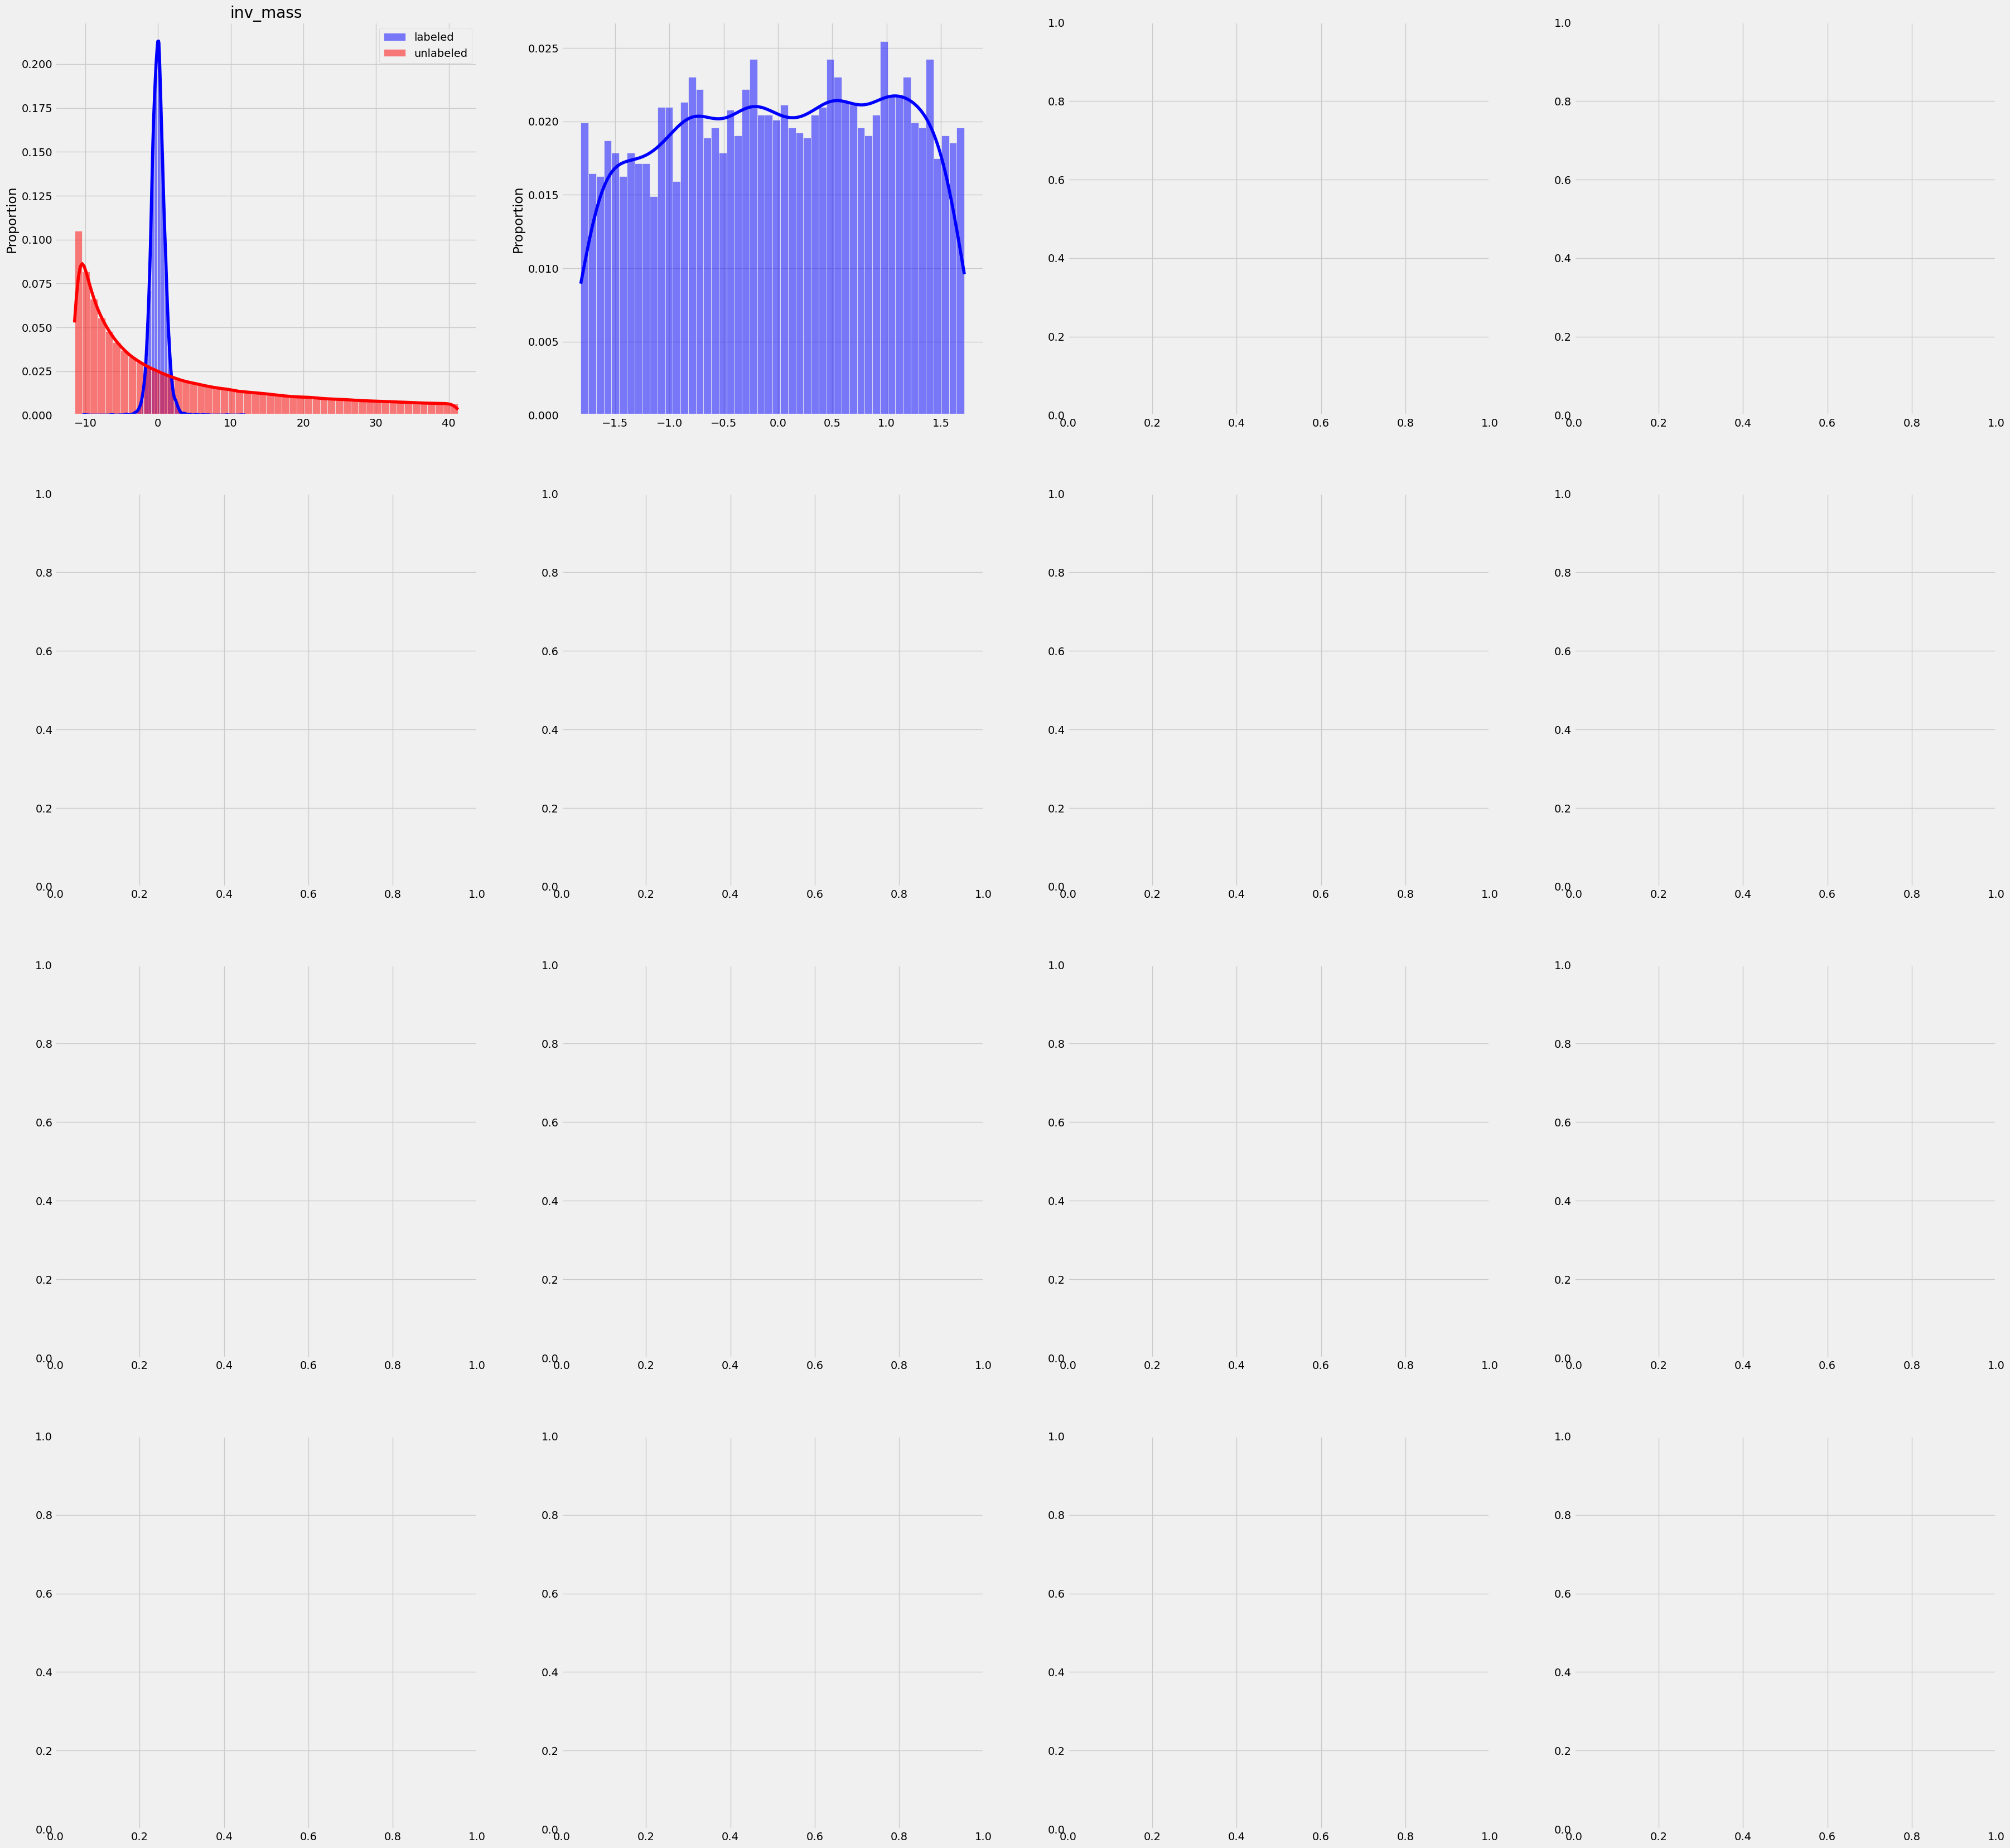

In [ ]:
from torch.utils.data import ConcatDataset
# Normalize each feature, according to the type of distribution it seems to follow to optimise performance

#! TODO explain the differences in transformation methods, and why different methods do and do not work here
# de quantiletransformer kan niet worden gefit op de trainingsdata bijvoorbeeld en dan gebruikt op beide, omdat die data buiten bereik van trainingsdata clipt.

qt = PowerTransformer(method="yeo-johnson",standardize=True)
qt.fit(labeled_anomaly_data_tensor)

labeled_anomaly_data_tensor_normalised = qt.transform(labeled_anomaly_data_tensor).astype(np.float32)
label__labeled_data_tensor = torch.tensor(np.ones(labeled_anomaly_data_tensor.shape[0]))
unlabeled_data_tensor_normalised = qt.transform(unlabeled_data_tensor).astype(np.float32)
label_unlabeled_data_tensor = torch.tensor(np.zeros(unlabeled_data_tensor_normalised.shape[0]))

# Split the data into:
# 1. a labeled anomaly training set, to train the KDAE on
# 2. A mix of labeled anomaly data and unlabeled noise, to verify the KDAE on
labeled_train, labeled_test = train_test_split(labeled_anomaly_data_tensor_normalised,test_size=0.2) # Use this to train the model
# mixed_data_tensor = labeled_test+unlabeled_data_tensor_normalised # Use this to find whether the model can separate the D+ from the not D+

fig, axes = plt.subplots(4,4, figsize=(40, 40))
axes = axes.flatten()
for i, col in enumerate(branches):
    sns.histplot(labeled_anomaly_data_tensor_normalised[:, i], bins=50, color='blue', alpha=0.5, label='labeled', ax=axes[i],kde=True,stat='proportion')
    sns.histplot(unlabeled_data_tensor_normalised[:, i], bins=50, color='red', alpha=0.5, label='unlabeled', ax=axes[i],kde=True,stat='proportion')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()
# dataset_test = TensorDataset(features_test)     # No labels
# loader_test = DataLoader(dataset_test, batch_size=2000, shuffle=True)
labeled_tensor = torch.tensor(labeled_anomaly_data_tensor_normalised)
unlabeled_tensor = torch.tensor(unlabeled_data_tensor_normalised)
labeled_inv_mass = labeled_tensor[:,0]
unlabeled_inv_mass = unlabeled_tensor[:,0]
labeled_tensor = labeled_tensor[:,[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]]
unlabeled_tensor = unlabeled_tensor[:,[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]]

# train_data, val_data = random_split(labeled_tensor, [1200, 600])
labeled_dataset = TensorDataset(labeled_tensor,label__labeled_data_tensor,labeled_inv_mass)
unlabeled_dataset = TensorDataset(unlabeled_tensor,label_unlabeled_data_tensor,unlabeled_inv_mass)

train_size = int(0.8 * len(labeled_dataset))
test_size = len(labeled_dataset) - train_size

# Split the dataset
KDAE_train_dataset, labeled_test_dataset = random_split(labeled_dataset, [train_size,test_size],generator=torch.Generator().manual_seed(42))

# 
loader_noise_data = DataLoader(unlabeled_dataset, batch_size=2000)
loader_KDAE_train_data = DataLoader(KDAE_train_dataset, batch_size=2000, shuffle=True)
KDAE_test_data = ConcatDataset([labeled_test_dataset,unlabeled_dataset])
loader_mixed_data = DataLoader(KDAE_test_data, batch_size=2000, shuffle=True)


Definieer de Auto Encoder

In [3]:
# Definieer een auto encoder neural network. Dit type neural network bgint met de volledige 16 parameters, comprimeert ze in steeds kleinere lagen
# Totdat het de kleinste laag van maar twee neuronen bereikt. Daarna probeert het hiermee weer de originele parameters te recreeëren
# Dit model leert dus voor het signaal van D+ deeltjes hoe de data er ongeveer uitziet. Het verschil tussen de input en output parameters
# Voor D+ deeltjes zou dus heel klein moeten zijn, en de error dus klein. Maar het model is niet getrained op alle andere deeltjes.
# De verwachting is dus dat andere deeltjes die geen D+ deeltjes zijn, de autoencoder heel slecht zal zijn in de parameters recreeëren zonder extra training.
# Zo kan de error van het netwerk gebruikt worden als classificatie van wel of niet D+ deeltjes.

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.shrinking = nn.Sequential(
            nn.Linear(15, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.1),
            nn.Linear(16, 8),
            nn.LeakyReLU(0.1),
            nn.Linear(8, 4)   # 2D latent space for KDE
        )
        self.growing = nn.Sequential(
            nn.Linear(4, 8),
            nn.LeakyReLU(0.1),
            nn.Linear(8, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.1),
            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.Linear(32, 15)
        )

    def forward(self, x):
        return self.growing(self.shrinking(x))


Train de auto-encoder

In [4]:
import torch
import torch.nn.functional as F

def kde_loss(latent, bandwidth=0.1):
    """
    Computes the KDE peak (maximum density) for each latent dimension.

    Args:
        latent: Tensor of shape (batch_size, latent_dim)
        bandwidth: Bandwidth for the Gaussian kernel

    Returns:
        peaks: Tensor of shape (latent_dim,) containing KDE peak per dimension
    """
    batch_size, latent_dim = latent.shape
    peaks = []

    norm_const = bandwidth * torch.sqrt(torch.tensor(2.0 * torch.pi, device=latent.device))

    for j in range(latent_dim):
        z = latent[:, j].unsqueeze(1)          # (N, 1)
        diff = z - z.T                         # (N, N)

        k = torch.exp(-0.5 * (diff / bandwidth) ** 2) / norm_const
        kde = k.sum(dim=1) / batch_size        # KDE estimate at each sample

        peak = kde.max()                       # KDE peak
        peaks.append(peak)

    return torch.stack(peaks).mean()


def loss_function(reconstructed, features, latent, alpha=.3):
    """
    Combined loss: reconstruction + amplified latent representation
    Args:
        reconstructed: Tensor of shape (batch_size, feature_dim)
        features: Original input tensor (batch_size, feature_dim)
        latent: Latent representation tensor (batch_size, latent_dim)
        alpha: Weight for latent loss
    Returns:
        total_loss: Scalar tensor
    """
    # Reconstruction loss: MAE
    Lc = F.l1_loss(reconstructed, features, reduction='mean')
    
    # Size of the peak of the kde in the latent layers. Encourage a large peak in the kde of the latent layer, as done in the paper referred to earlier.
    Lr = kde_loss(latent)
    
    # Total loss
    total_loss = Lc - alpha * Lr
    return total_loss


In [5]:
model_2D = Autoencoder()

optimizer = optim.Adam(model_2D.parameters(), lr=1e-3, weight_decay=1e-5)
epochs = 300
outputs = []
losses = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_2D.to(device)
loss_vs_epoch = []


for epoch in range(epochs):
    total_loss = 0
    for batch, label, inv_mass in loader_KDAE_train_data:
        features = batch.to(device)
        
        reconstructed = model_2D(features)
        latent = model_2D.shrinking(features)
        loss = loss_function(reconstructed, features,latent)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    loss_vs_epoch.append(total_loss)
    outputs.append((epoch, features, reconstructed))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.6f}")

plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(loss_vs_epoch, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

NameError: name 'loader_KDAE_train_data' is not defined

Plot de score van het model om te onderscheiden tussen de gelabelde en ongelabelde data

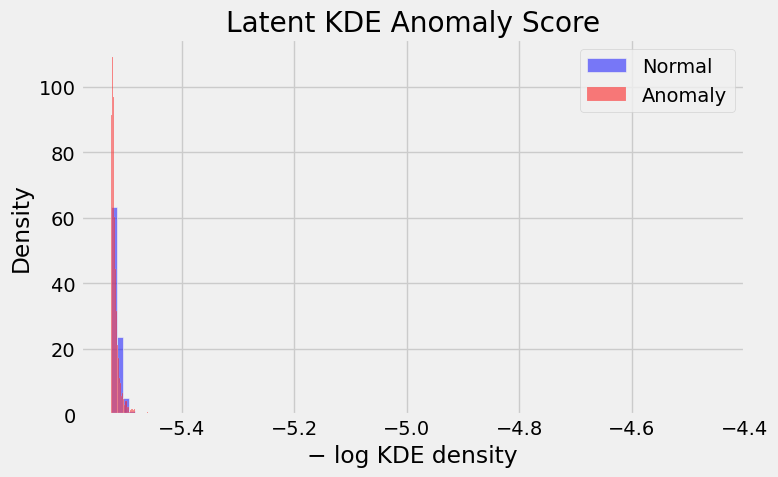

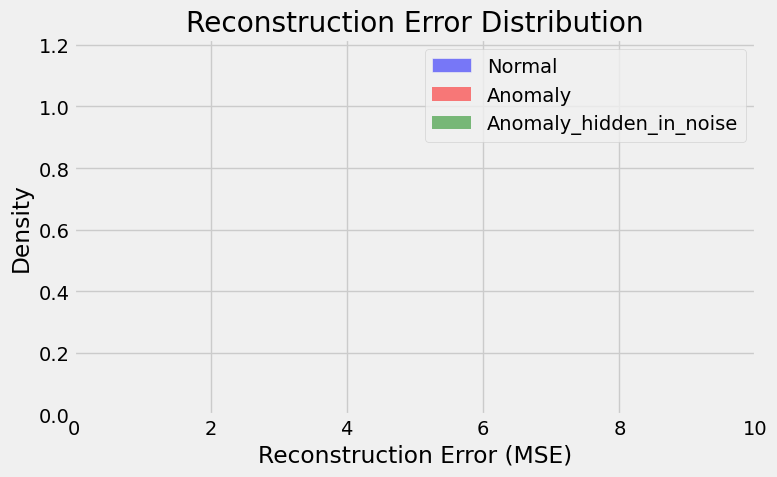

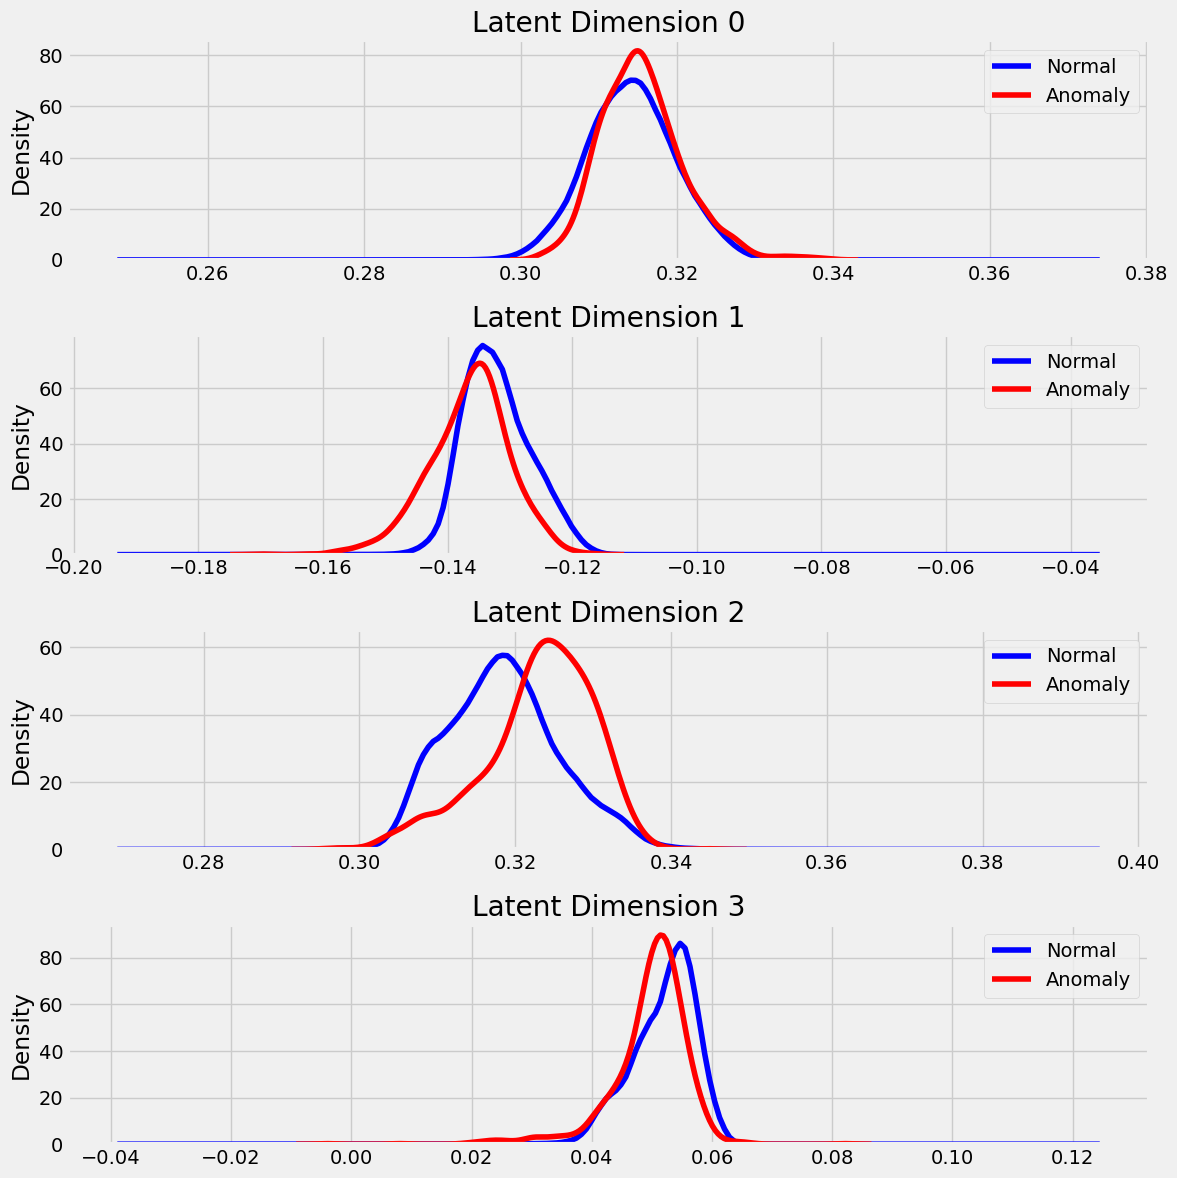

In [ ]:
import torch
import numpy as np
from sklearn.neighbors import KernelDensity
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns


def collect_latent_and_error(model, dataloader, device):
    model.eval()

    latents = []
    recon_errors = []
    labels = []

    with torch.no_grad():
        for x, y, inv_mass in dataloader:
            x = x.to(device).float()

            z = model.shrinking(x)
            recon = model(x)

            recon_error = -torch.mean((x - recon) ** 2, dim=1)

            latents.append(z.cpu().numpy())
            recon_errors.append(recon_error.cpu().numpy())
            labels.append(y.cpu().numpy())

    return (
        np.vstack(latents),
        np.concatenate(recon_errors),
        np.concatenate(labels),
    )

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model_2D
model.to(device)

# Collect TRAIN (normal) data
latent_train, recon_train, y_train = collect_latent_and_error(
    model, loader_KDAE_train_data, device
)

# KDE fitted ONLY on (mostly) normal data
kde = KernelDensity(
    kernel="gaussian",
    bandwidth=0.1  # tune this!
).fit(latent_train)

latent_test, recon_test, y_test = collect_latent_and_error(
    model, loader_mixed_data, device
)

# KDE log-likelihood
log_density_test = kde.score_samples(latent_test)
log_density_train = kde.score_samples(latent_train)

# Anomaly scores
# (higher = more anomalous)
anomaly_score_kde = -log_density_test
anomaly_score_recon = -log_density_train


plt.figure(figsize=(8, 5))
sns.histplot(
    anomaly_score_kde[y_test == 0],
    bins=100,
    stat="density",
    label="Normal",
    color="blue",
    alpha=0.5,
)
sns.histplot(
    anomaly_score_kde[y_test == 1],
    bins=100,
    stat="density",
    label="Anomaly",
    color="red",
    alpha=0.5,
)

plt.xlabel("− log KDE density")
plt.title("Latent KDE Anomaly Score")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(
    recon_test[y_test == 0],
    bins=100,
    stat="density",
    label="Normal",
    color="blue",
    alpha=0.5,
)
sns.histplot(
    recon_test[y_test == 1],
    bins=100,
    stat="density",
    label="Anomaly hidden in noise",
    color="red",
    alpha=0.5,
)

sns.histplot(
    recon_train[y_train == 1],
    bins=100,
    stat="density",
    label="Anomaly",
    color="green",
    alpha=0.5,
)
plt.xlabel("Reconstruction Error (MSE)")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.tight_layout()
plt.show()

latent_dim = latent_test.shape[1]
fig, axes = plt.subplots(latent_dim, 1, figsize=(12, 3 * latent_dim))

for i in range(latent_dim):
    sns.kdeplot(
        latent_test[y_test == 0, i],
        label="Normal",
        color="blue",
        ax=axes[i],
    )
    sns.kdeplot(
        latent_test[y_test == 1, i],
        label="Anomaly",
        color="red",
        ax=axes[i],
    )
    axes[i].set_title(f"Latent Dimension {i}")
    axes[i].legend()

plt.tight_layout()
plt.show()



              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97   4677168
         1.0       0.00      0.67      0.01      1155

    accuracy                           0.94   4678323
   macro avg       0.50      0.80      0.49   4678323
weighted avg       1.00      0.94      0.97   4678323

Confusion matrix:
 [[4388946  288222]
 [    386     769]]
1155 true outlier amount


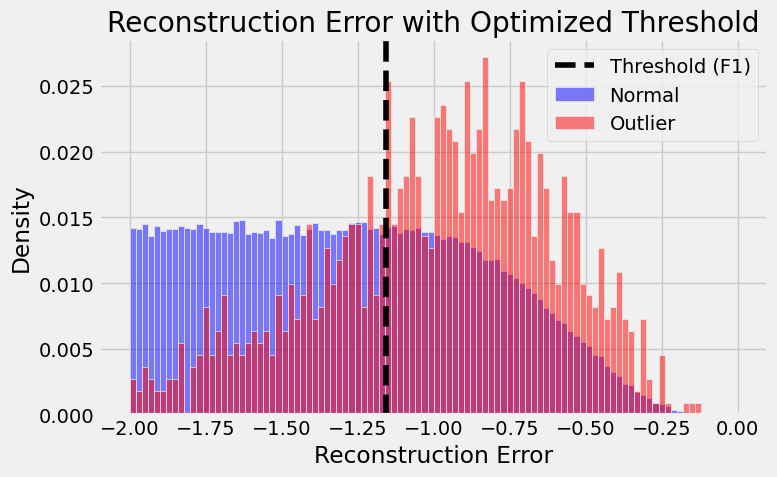

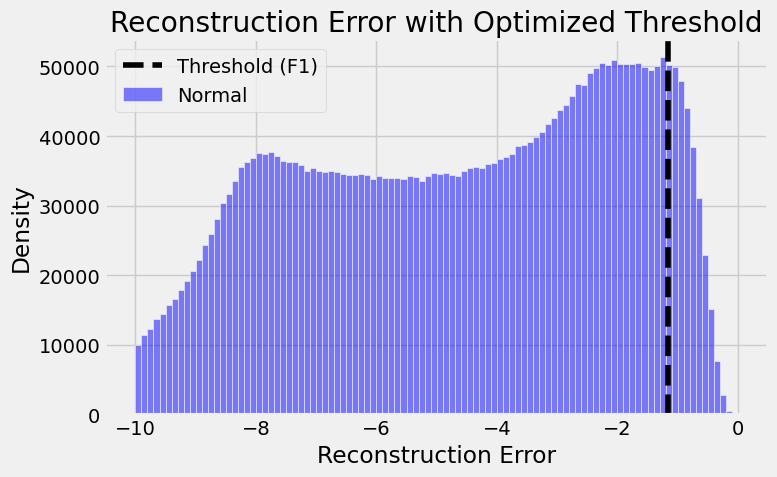

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, classification_report, confusion_matrix, f1_score

# --- Precision-Recall based threshold (max F1) ---
precision, recall, pr_thresholds = precision_recall_curve(y_test, recon_test)
beta = 10
f_beta = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall + 1e-8)
best_idx = np.argmax(f_beta)
best_threshold_f1 = pr_thresholds[best_idx]

# --- Predicted labels ---\
pred_labels = (recon_test > best_threshold_f1).astype(int)
signal_mask = recon_test > best_threshold_f1

# --- Performance evaluation ---
print(classification_report(y_test, pred_labels))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_labels))
print(len(recon_test[y_test == 1]), "true outlier amount")

# --- Visualization ---
plt.figure(figsize=(8,5))
sns.histplot(recon_test[y_test==0], color='blue', label='Normal', bins=100,binrange=(-2,0), alpha=0.5,stat='proportion')
sns.histplot(recon_test[y_test==1], color='red', label='Outlier', bins=100,binrange=(-2,0), alpha=0.5,stat='proportion')
plt.axvline(best_threshold_f1, color='black', linestyle='--', label='Threshold (F1)')
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Reconstruction Error with Optimized Threshold")
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(8,5))
sns.histplot(recon_test, color='blue', label='Normal', bins=100,binrange=(-10,0), alpha=0.5)
plt.axvline(best_threshold_f1, color='black', linestyle='--', label='Threshold (F1)')
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Reconstruction Error with Optimized Threshold")
plt.legend()
plt.tight_layout()
plt.show()


Optimized threshold (Youden index): 10.982195719945107
Optimized threshold (max F1): 10.982195719945107
              precision    recall  f1-score   support

         0.0       1.00      0.52      0.68   4677168
         1.0       0.00      0.57      0.00      1155

    accuracy                           0.52   4678323
   macro avg       0.50      0.54      0.34   4678323
weighted avg       1.00      0.52      0.68   4678323

Confusion matrix:
 [[2409833 2267335]
 [    501     654]]
1155 true outlier amount


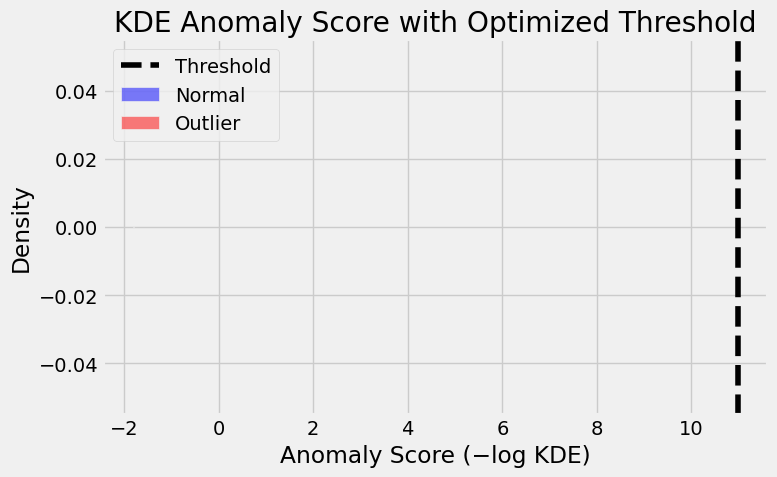

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score

fpr, tpr, thresholds = roc_curve(y_test, log_density_test)
youden_index = tpr - fpr
best_threshold = thresholds[np.argmax(youden_index)]
print("Optimized threshold (Youden index):", best_threshold)

precision, recall, pr_thresholds = precision_recall_curve(y_test, log_density_test)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold_f1 = pr_thresholds[np.argmax(f1_scores)]
print("Optimized threshold (max F1):", best_threshold)

pred_labels = (log_density_test > best_threshold).astype(int)
signal_mask = log_density_test > best_threshold



# Optional: check performance
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, pred_labels))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_labels))
print(len(log_density_test[y_test==1]),"true outlier amount")
plt.figure(figsize=(8,5))
sns.histplot(log_density_test[y_test==0], color='blue', label='Normal', binrange=(-1.810,-1.805),bins=100, alpha=0.5)
sns.histplot(log_density_test[y_test==1], color='red', label='Outlier', binrange=(-1.810,-1.805),bins=100, alpha=0.5)
plt.axvline(best_threshold, color='black', linestyle='--', label='Threshold')
plt.xlabel("Anomaly Score (−log KDE)")
plt.ylabel("Density")
plt.title("KDE Anomaly Score with Optimized Threshold")
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
# We have now classified the signal from the background (not necessarily very well). Give the signal we found in the background noise a label D+ = True

X_Dplus_candidates = []
X_Dplus_noise = []

def find_signal_noise(model, dataloader, device):
    model.eval()

    candidates = []
    recon_errors = []
    labels = []
    i=0
    with torch.no_grad():
        for x, y, inv_mass in dataloader:
            x = x.to(device).float()
            i+=1
            print(i)
            recon = model(x)

            recon_error = -torch.mean((x - recon) ** 2, dim=1)
            candidate = recon_error>best_threshold_f1
            recon_errors.append(recon_error.cpu().numpy())
            candidates.append(candidate.cpu().numpy())
            labels.append(x)

    return (
        np.concatenate(candidates),
        np.concatenate(recon_errors),
        np.concatenate(labels),
    )

model_2D.eval()
i=0
print(len(loader_noise_data))
with torch.no_grad():
    candidates, recon_train, params = find_signal_noise(
        model, loader_noise_data, device
    )



# Concatenate once
X_Dplus_candidates = params[candidates]
X_Dplus_noise = params[~candidates]



# print(len(X_Dplus_noise))

2339
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276

[ 2.0351543  -0.4679918  -1.3953569  -1.5210166  -2.1206715  -0.4135002
 -1.6897302   0.5357886  -0.1267417   0.88020164 -1.5090549   0.8362321
 -1.3632457   1.2537694   0.22680053  1.3105152 ]


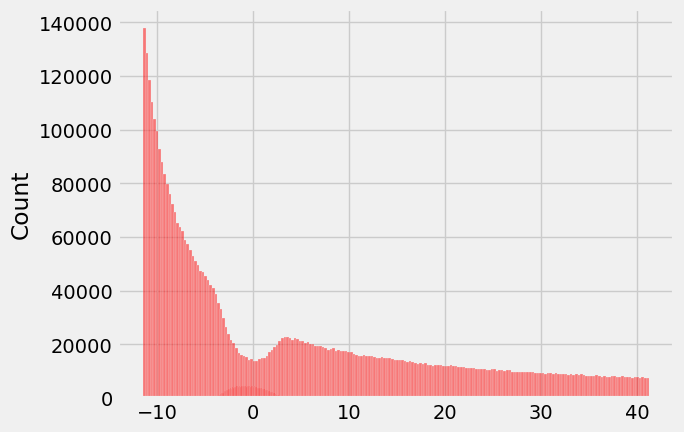

<Figure size 800x500 with 0 Axes>

In [ ]:
sns.histplot(X_Dplus_candidates[:,0], color='red', label='Outlier', alpha=0.5)
sns.histplot(X_Dplus_noise[:,0], color='red', label='Outlier', alpha=0.5)
print(X_Dplus_candidates[0])
plt.figure(figsize=(8,5))
plt.show()

In [ ]:

# x = labeled_tensor.to(device).float()
# with torch.no_grad():
#     y = model_2D.forward(x)

# x_test = unlabeled_tensor.to(device).float()
# with torch.no_grad():
#     y_test = model_2D.forward(x_test)


# # Column names
# columns = branches

# # Plot histograms for each feature
# fig, axes = plt.subplots(4,4, figsize=(40, 40))
# axes = axes.flatten()

# for i, col in enumerate(columns):
#     sns.histplot(x_test[:,i], bins=50, color='blue', alpha=0.5, label='test_input', ax=axes[i],kde=True,stat='proportion')
#     sns.histplot(y_test[:,i], bins=50, color='red', alpha=0.5, label='test_output', ax=axes[i],kde=True,stat='proportion')
#     sns.histplot(x[:,i], bins=50, color='black', alpha=0.5, label='train_input', ax=axes[i],kde=True,stat='proportion')
#     sns.histplot(y[:,i], bins=50, color='green', alpha=0.5, label='train_output', ax=axes[i],kde=True,stat='proportion')
#     axes[i].set_title(col)
#     axes[i].legend()

# plt.tight_layout()
# plt.show()

In [ ]:
# import seaborn as sns
# def loader_to_tensor(loader):
#     all_data = []
#     for batch in loader:
#         # batch is a tuple (features,) because no labels
#         all_data.append(batch[0])
#     return torch.cat(all_data, dim=0)
# # Convert train and test loaders
# train_tensor = loader_to_tensor(loader)
# test_tensor = loader_to_tensor(loader_test)

# # Convert to numpy for plotting
# train_np = train_tensor.numpy()
# test_np = test_tensor.numpy()

# # Column names
# columns = ['inv_mass','d_len','pt_cand','d_len_xy']

# # Plot histograms for each feature
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# axes = axes.flatten()

# for i, col in enumerate(columns):
#     sns.histplot(train_np[:, i], bins=50, color='blue', alpha=0.5, label='Train', ax=axes[i],kde=True,stat='proportion')
#     sns.histplot(test_np[:, i], bins=50, color='red', alpha=0.5, label='Test', ax=axes[i],kde=True,stat='proportion')
#     axes[i].set_title(col)
#     axes[i].legend()

# plt.tight_layout()
# plt.show()